# UK Economic Pulse — Dashboard Build

This notebook builds the Streamlit dashboard step by step.

Each section is self-contained and prints output so you can validate before moving on.

**Structure:**
1. Imports
2. Load your CSV files
3. Series catalogue — what we're tracking and why
4. Helper functions — latest value, MoM change, direction arrow
5. Scorecard preview — validate each indicator looks right
6. Sparkline charts — 36-month trend per series
7. Contextual pairs — the relationships that matter
8. Series explorer — full history for any indicator
9. Export to app.py — write the final Streamlit file

---

> **Note:** Sections 1–8 run entirely in Jupyter using `matplotlib`.
> Section 9 writes `app.py` which you then run with `streamlit run app.py`.

## 1. Imports

In [1]:
import os
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Notebook display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('dark_background')

print('Imports OK')

Imports OK


## 2. Load CSV files

Update the paths below to match your local setup.

In [2]:
ABS_PATH = '/Users/ornettematthews/Documents/GitHub/uk-economic-pulse/data/raw/absolute_values.csv'
SIG_PATH = '/Users/ornettematthews/Documents/GitHub/uk-economic-pulse/data/raw/signals.csv'

abs_df = pd.read_csv(ABS_PATH, index_col=0, parse_dates=True)
sig_df = pd.read_csv(SIG_PATH, index_col=0, parse_dates=True)

abs_df.index = pd.to_datetime(abs_df.index)
sig_df.index = pd.to_datetime(sig_df.index)

# Derive yield curve if not already in signals
if 'uk_yield_curve' not in sig_df.columns:
    if 'yield_uk_10y' in abs_df.columns and 'yield_uk_3m' in abs_df.columns:
        sig_df['uk_yield_curve'] = abs_df['yield_uk_10y'] - abs_df['yield_uk_3m']
        print('Derived uk_yield_curve from absolute_values')

print(f'absolute_values: {abs_df.shape[0]} rows × {abs_df.shape[1]} cols')
print(f'signals:         {sig_df.shape[0]} rows × {sig_df.shape[1]} cols')
print(f'Date range:      {sig_df.index.min().date()} → {sig_df.index.max().date()}')

absolute_values: 953 rows × 26 cols
signals:         953 rows × 29 cols
Date range:      1947-01-31 → 2026-05-31


In [5]:
# Quick sanity check — last 3 rows of signals
sig_df.tail(5).T

,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
gdp_growth_yoy,NaN,NaN,NaN,NaN,NaN
gdp_growth_yoy_us,2.66,NaN,NaN,NaN,NaN
house_prices_yoy,NaN,NaN,NaN,NaN,NaN
retail_sales_yoy,4.64,1.88,1.67,NaN,NaN
cpi_yoy,3.03,3.01,3.30,NaN,NaN
real_wages_yoy,1.57,0.58,NaN,NaN,NaN
unemployment_rate,4.90,NaN,NaN,NaN,NaN
participation_rate,79.00,NaN,NaN,NaN,NaN
policy_rate,3.75,3.75,3.75,3.75,3.75
yield_us_2y,3.54,3.47,3.71,3.80,3.92


## 3. Series Catalogue

This is the master list of everything we display.

Each entry defines:
- `signal_col` — the column name in `signals.csv`
- `unit` — what the number means
- `higher_is_better` — drives green/red colouring
- `lag` — how stale the data typically is

Add or remove entries here to change what appears on the dashboard.

In [6]:
CATALOGUE = [
    # ── Economic Activity ──────────────────────────────────────────────────
    dict(key='gdp',      label='UK GDP Growth',       category='Economic Activity',
         signal_col='gdp_growth_yoy',    unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Quarterly · ~2m lag'),

    dict(key='retail',   label='Retail Sales',        category='Economic Activity',
         signal_col='retail_sales_yoy',  unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Monthly · ~4w lag'),

    dict(key='house',    label='House Prices',        category='Economic Activity',
         signal_col='house_prices_yoy',  unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Quarterly · ~2m lag'),

    # ── Labour Market ──────────────────────────────────────────────────────
    dict(key='unemp',    label='Unemployment Rate',   category='Labour Market',
         signal_col='unemployment_rate', unit='%',     decimals=1,
         higher_is_better=False, lag='Monthly · ~6w lag'),

    dict(key='particip', label='Labour Participation',category='Labour Market',
         signal_col='participation_rate',unit='%',     decimals=1,
         higher_is_better=True,  lag='Monthly · ~6w lag'),

    # ── Inflation Pressure ─────────────────────────────────────────────────
    dict(key='cpi',      label='CPI Inflation',       category='Inflation Pressure',
         signal_col='cpi_yoy',           unit='% YoY', decimals=1,
         higher_is_better=False, lag='Monthly · ~3w lag'),

    dict(key='realwage', label='Real Wage Growth',    category='Inflation Pressure',
         signal_col='real_wages_yoy',    unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Monthly · ~6w lag'),

    # ── Financial Conditions ───────────────────────────────────────────────
    dict(key='polrate',  label='BoE Policy Rate',     category='Financial Conditions',
         signal_col='policy_rate',       unit='%',     decimals=2,
         higher_is_better=False, lag='Real-time'),

    dict(key='uk10y',    label='UK 10Y Gilt Yield',   category='Financial Conditions',
         signal_col='yield_uk_10y',      unit='%',     decimals=2,
         higher_is_better=False, lag='Monthly mean'),

    dict(key='ukcrv',    label='UK Yield Curve',      category='Financial Conditions',
         signal_col='uk_yield_curve',    unit='pp (10Y−3M)', decimals=2,
         higher_is_better=True,  lag='Monthly'),

    dict(key='hyspread', label='US HY Credit Spread', category='Financial Conditions',
         signal_col='spread_us_hy',      unit='pp',    decimals=2,
         higher_is_better=False, lag='Daily · since 2023'),

    # ── Commodities ────────────────────────────────────────────────────────
    dict(key='oil',      label='Brent Oil',           category='Commodities',
         signal_col='oil_yoy',           unit='% YoY', decimals=1,
         higher_is_better=False, lag='Monthly mean'),

    dict(key='copper',   label='Copper',              category='Commodities',
         signal_col='copper_yoy',        unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Monthly mean'),

    dict(key='natgas',   label='Natural Gas',         category='Commodities',
         signal_col='nat_gas_yoy',       unit='% YoY', decimals=1,
         higher_is_better=False, lag='Monthly mean'),

    dict(key='gold',     label='Gold',                category='Commodities',
         signal_col='gold_yoy',          unit='% YoY', decimals=1,
         higher_is_better=False, lag='Monthly mean'),

    # ── Markets ────────────────────────────────────────────────────────────
    dict(key='dxy',      label='US Dollar (DXY)',     category='Markets',
         signal_col='dxy_yoy',           unit='% YoY', decimals=1,
         higher_is_better=False, lag='Monthly mean'),

    dict(key='sox',      label='Semiconductors (SOX)',category='Markets',
         signal_col='sox_yoy',           unit='% YoY', decimals=1,
         higher_is_better=True,  lag='Monthly mean'),
]

CATEGORY_ORDER = [
    'Economic Activity',
    'Labour Market',
    'Inflation Pressure',
    'Financial Conditions',
    'Commodities',
    'Markets',
]

# Check which catalogue entries we actually have data for
print('Coverage check:')
for spec in CATALOGUE:
    col = spec['signal_col']
    if col in sig_df.columns:
        s = sig_df[col].dropna()
        last = s.index[-1].strftime('%b %Y') if not s.empty else 'no data'
        print(f"  ✓  {spec['label']:<28} last: {last}")
    else:
        print(f"  ✗  {spec['label']:<28} MISSING — column '{col}' not in signals.csv")

Coverage check:
  ✓  UK GDP Growth                last: Oct 2025
  ✓  Retail Sales                 last: Mar 2026
  ✓  House Prices                 last: Oct 2025
  ✓  Unemployment Rate            last: Jan 2026
  ✓  Labour Participation         last: Jan 2026
  ✓  CPI Inflation                last: Mar 2026
  ✓  Real Wage Growth             last: Feb 2026
  ✓  BoE Policy Rate              last: May 2026
  ✓  UK 10Y Gilt Yield            last: Mar 2026
  ✓  UK Yield Curve               last: Jan 2026
  ✓  US HY Credit Spread          last: May 2026
  ✓  Brent Oil                    last: May 2026
  ✓  Copper                       last: May 2026
  ✓  Natural Gas                  last: May 2026
  ✓  Gold                         last: May 2026
  ✓  US Dollar (DXY)              last: May 2026
  ✓  Semiconductors (SOX)         last: May 2026


## 4. Helper Functions

Small, single-purpose functions. Each one does exactly one thing.

In [7]:
def latest_valid(series: pd.Series):
    """Return (value, date) of the most recent non-null observation."""
    s = series.dropna()
    if s.empty:
        return None, None
    return s.iloc[-1], s.index[-1]


def mom_change(series: pd.Series):
    """Change in signal value from the prior month's reading.
    
    For a YoY series this is: this month's YoY% minus last month's YoY%.
    For a level series (e.g. policy rate) this is the raw pp change.
    """
    s = series.dropna()
    if len(s) < 2:
        return None
    return s.iloc[-1] - s.iloc[-2]


def fmt(v, decimals=1):
    """Format a number for display. Returns '—' for missing."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return '—'
    return f'{v:.{decimals}f}'


def arrow_and_colour(chg, higher_is_better=True):
    """Return (arrow_str, colour_hex) based on direction and whether up is good."""
    GREEN = '#4caf7d'
    RED   = '#e05a4e'
    GREY  = '#8a8a8a'

    if chg is None or abs(chg) < 0.001:
        return '→', GREY
    going_up = chg > 0
    good_move = going_up == higher_is_better
    symbol = '↑' if going_up else '↓'
    colour = GREEN if good_move else RED
    return symbol, colour


def data_age_months(date):
    """How many months old is this observation?"""
    if date is None:
        return 999
    return (pd.Timestamp.now() - date).days / 30


# Quick test
test = sig_df['cpi_yoy'].dropna()
val, dt = latest_valid(test)
chg     = mom_change(test)
arr, col = arrow_and_colour(chg, higher_is_better=False)

print(f'CPI YoY — latest: {fmt(val)}%  date: {dt.strftime("%b %Y")}  MoM change: {fmt(chg)} pp  arrow: {arr}')

CPI YoY — latest: 3.3%  date: Mar 2026  MoM change: 0.3 pp  arrow: ↑


## 5. Scorecard Preview

Print a text scorecard for every indicator in the catalogue.

This is the validation step — check every number looks right before we build the visuals.

In [8]:
current_category = None

for spec in CATALOGUE:
    col = spec['signal_col']
    
    if spec['category'] != current_category:
        current_category = spec['category']
        print(f'\n── {current_category.upper()} ──────────────────────────────')

    if col not in sig_df.columns:
        print(f"  {spec['label']:<28} NO DATA")
        continue

    series = sig_df[col]
    val, dt   = latest_valid(series)
    chg       = mom_change(series)
    arr, _    = arrow_and_colour(chg, spec['higher_is_better'])
    date_str  = dt.strftime('%b %Y') if dt else '—'
    chg_str   = f'{arr} {fmt(chg, spec["decimals"]):>7} MoM' if chg is not None else '         —'
    age       = data_age_months(dt)
    freshness = 'CURRENT' if age <= 2 else ('LAGGED' if age <= 5 else 'STALE')

    print(f"  {spec['label']:<28} {fmt(val, spec['decimals']):>8} {spec['unit']:<14} {chg_str}   {date_str}  [{freshness}]")


── ECONOMIC ACTIVITY ──────────────────────────────
  UK GDP Growth                     1.0 % YoY          ↓    -0.3 MoM   Oct 2025  [STALE]
  Retail Sales                      1.7 % YoY          ↓    -0.2 MoM   Mar 2026  [CURRENT]
  House Prices                     -0.9 % YoY          ↑     0.4 MoM   Oct 2025  [STALE]

── LABOUR MARKET ──────────────────────────────
  Unemployment Rate                 4.9 %              ↓    -0.3 MoM   Jan 2026  [LAGGED]
  Labour Participation             79.0 %              ↓    -0.3 MoM   Jan 2026  [LAGGED]

── INFLATION PRESSURE ──────────────────────────────
  CPI Inflation                     3.3 % YoY          ↑     0.3 MoM   Mar 2026  [CURRENT]
  Real Wage Growth                  0.6 % YoY          ↓    -1.0 MoM   Feb 2026  [LAGGED]

── FINANCIAL CONDITIONS ──────────────────────────────
  BoE Policy Rate                  3.75 %              →    0.00 MoM   May 2026  [CURRENT]
  UK 10Y Gilt Yield                4.70 %              ↑    0.27 Mo

## 6. Sparklines — 36-Month Trend Per Series

One small chart per indicator, grouped by category.

Green line = the move has been favourable. Red = unfavourable.

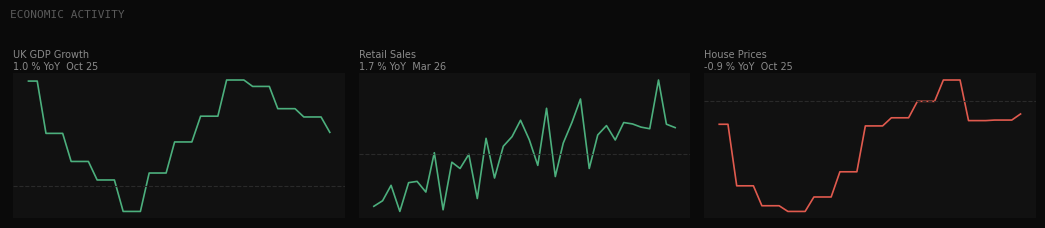

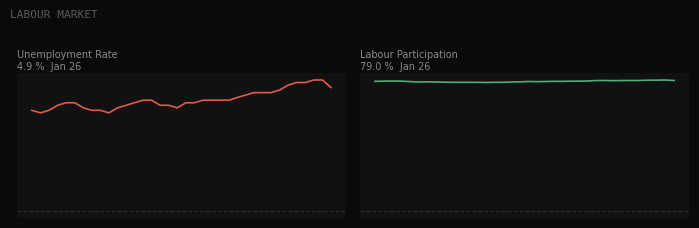

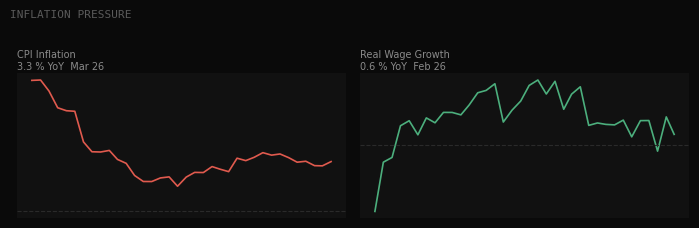

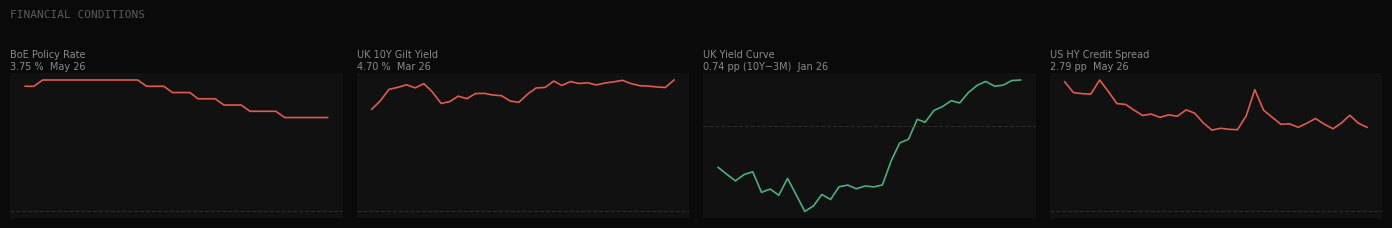

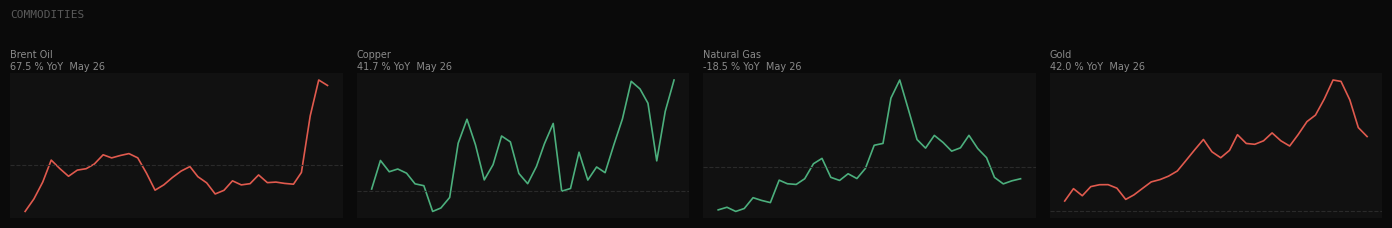

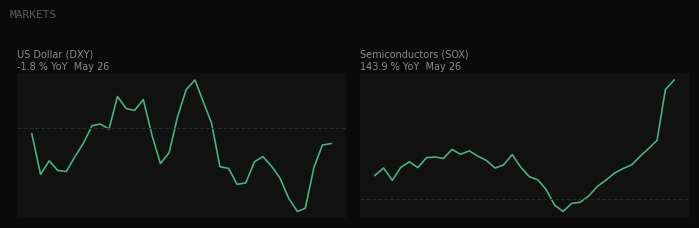

In [9]:
def plot_sparkline(ax, series: pd.Series, spec: dict, months: int = 36):
    """Plot a single sparkline on the given axes."""
    s = series.dropna().tail(months)
    if s.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='#5a5a5a', fontsize=8)
        ax.set_visible(True)
        return

    latest_val = s.iloc[-1]
    good = (latest_val >= 0) == spec['higher_is_better']
    colour = '#4caf7d' if good else '#e05a4e'

    ax.plot(s.index, s.values, color=colour, linewidth=1.2)
    ax.axhline(0, color='#2a2a2a', linewidth=0.8, linestyle='--')
    ax.set_facecolor('#111111')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Title with current value
    val, dt = latest_valid(series)
    date_str = dt.strftime('%b %y') if dt else ''
    ax.set_title(
        f"{spec['label']}\n{fmt(val, spec['decimals'])} {spec['unit']}  {date_str}",
        fontsize=7, color='#8a8a8a', loc='left', pad=3
    )


# ── Plot all categories ────────────────────────────────────────────────────
for cat in CATEGORY_ORDER:
    items = [s for s in CATALOGUE if s['category'] == cat]
    available = [s for s in items if s['signal_col'] in sig_df.columns]
    if not available:
        continue

    n = len(available)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.5, nrows * 2.2),
        facecolor='#0a0a0a'
    )
    axes = np.array(axes).flatten()

    fig.suptitle(cat.upper(), fontsize=8, color='#5a5a5a',
                 fontfamily='monospace', x=0.01, ha='left', y=1.01)

    for i, spec in enumerate(available):
        plot_sparkline(axes[i], sig_df[spec['signal_col']], spec)

    # Hide any unused axes
    for j in range(len(available), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(pad=1.0)
    plt.show()

## 7. Contextual Pairs

These are the four relationships that tell the real story.

- **CPI vs Real Wages** — is purchasing power recovering?
- **Policy Rate vs 10Y Gilt** — is the market pricing in cuts?
- **Copper vs DXY** — global demand signal (copper up + dollar down = risk-on)
- **Oil vs CPI** — how much of inflation is energy-driven?

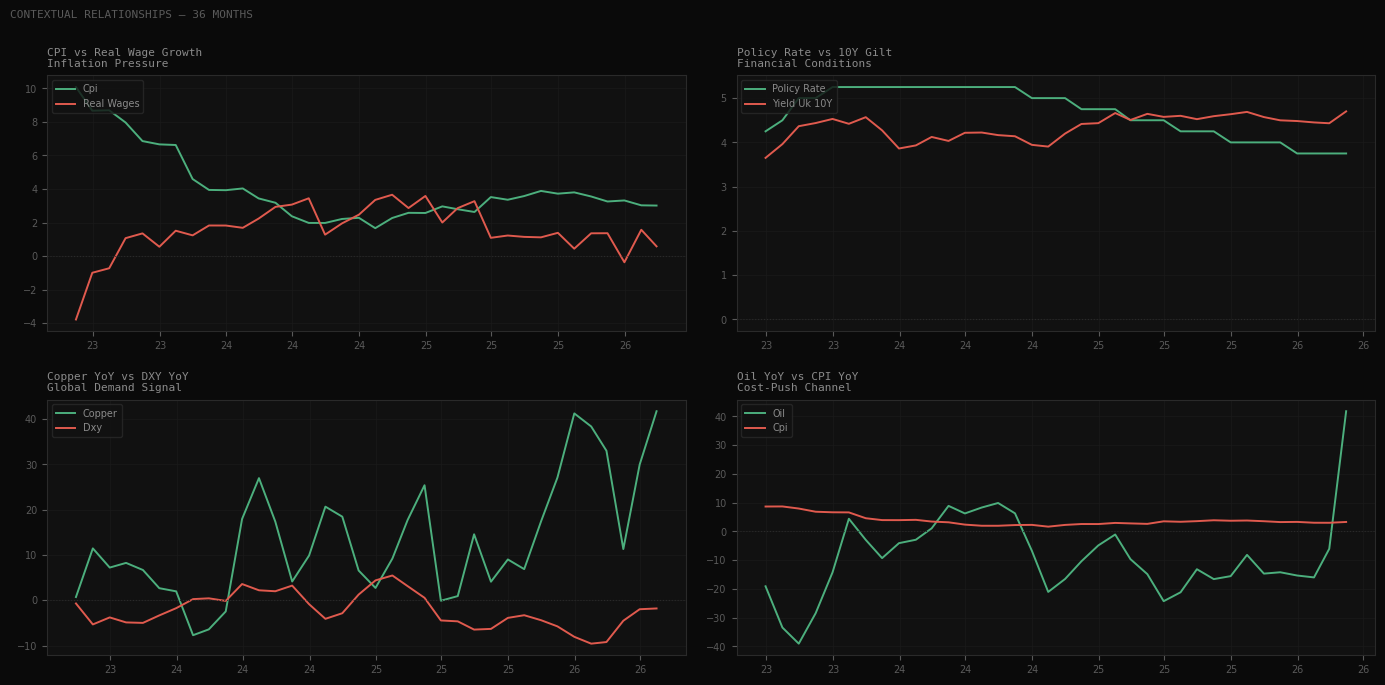

In [10]:
CONTEXT_PAIRS = [
    ('cpi_yoy',      'real_wages_yoy', 'CPI vs Real Wage Growth',   'Inflation Pressure'),
    ('policy_rate',  'yield_uk_10y',   'Policy Rate vs 10Y Gilt',   'Financial Conditions'),
    ('copper_yoy',   'dxy_yoy',        'Copper YoY vs DXY YoY',     'Global Demand Signal'),
    ('oil_yoy',      'cpi_yoy',        'Oil YoY vs CPI YoY',        'Cost-Push Channel'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), facecolor='#0a0a0a')
axes = axes.flatten()

for i, (col_a, col_b, title, subtitle) in enumerate(CONTEXT_PAIRS):
    ax = axes[i]
    ax.set_facecolor('#111111')
    for spine in ax.spines.values():
        spine.set_color('#2a2a2a')
    ax.tick_params(colors='#5a5a5a', labelsize=7)

    sa = sig_df[col_a].dropna() if col_a in sig_df.columns else pd.Series(dtype=float)
    sb = sig_df[col_b].dropna() if col_b in sig_df.columns else pd.Series(dtype=float)

    both = pd.DataFrame({'a': sa, 'b': sb}).dropna().tail(36)

    if both.empty:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='#5a5a5a', fontsize=9)
    else:
        label_a = col_a.replace('_yoy','').replace('_',' ').title()
        label_b = col_b.replace('_yoy','').replace('_',' ').title()
        ax.plot(both.index, both['a'], color='#4caf7d', linewidth=1.4, label=label_a)
        ax.plot(both.index, both['b'], color='#e05a4e', linewidth=1.4, label=label_b)
        ax.axhline(0, color='#2a2a2a', linewidth=0.8, linestyle=':')
        ax.legend(fontsize=7, facecolor='#111111', edgecolor='#2a2a2a',
                  labelcolor='#8a8a8a', loc='upper left')

    ax.set_title(f'{title}\n{subtitle}', fontsize=8, color='#8a8a8a',
                 fontfamily='monospace', loc='left', pad=6)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%y'))
    ax.grid(color='#1a1a1a', linewidth=0.5)

plt.suptitle('CONTEXTUAL RELATIONSHIPS — 36 MONTHS', fontsize=8,
             color='#5a5a5a', fontfamily='monospace', x=0.01, ha='left')
plt.tight_layout(pad=1.5)
plt.show()

## 8. Series Explorer

Full history chart for any single indicator.

Change `EXPLORE` below to look at any series.

CPI Inflation
  Current:    3.3 % YoY  (Mar 2026)
  MoM change: ↑ 0.3 pp
  24M high:   3.9
  24M low:    1.7
  Data from:  Jan 1989


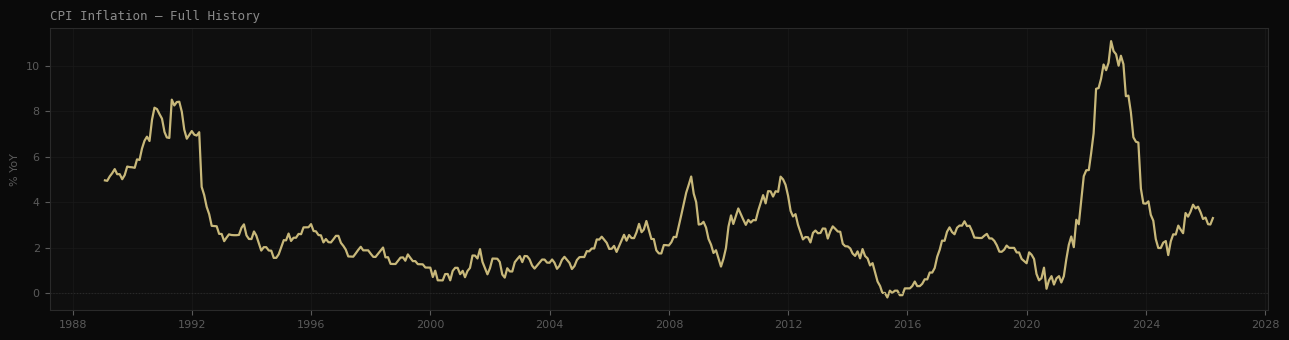

In [11]:
# Change this to any key from the catalogue
EXPLORE = 'cpi'

spec   = next(s for s in CATALOGUE if s['key'] == EXPLORE)
col    = spec['signal_col']
series = sig_df[col].dropna() if col in sig_df.columns else pd.Series(dtype=float)

if series.empty:
    print(f"No data for '{EXPLORE}'")
else:
    val, dt = latest_valid(series)
    chg     = mom_change(series)
    arr, _  = arrow_and_colour(chg, spec['higher_is_better'])
    s24     = series.tail(24)

    print(f"{spec['label']}")
    print(f"  Current:    {fmt(val, spec['decimals'])} {spec['unit']}  ({dt.strftime('%b %Y')})")
    print(f"  MoM change: {arr} {fmt(chg, spec['decimals'])} pp")
    print(f"  24M high:   {fmt(s24.max(), spec['decimals'])}")
    print(f"  24M low:    {fmt(s24.min(), spec['decimals'])}")
    print(f"  Data from:  {series.index[0].strftime('%b %Y')}")

    fig, ax = plt.subplots(figsize=(13, 3.5), facecolor='#0a0a0a')
    ax.set_facecolor('#0f0f0f')
    ax.plot(series.index, series.values, color='#c8b87a', linewidth=1.6)
    ax.axhline(0, color='#2a2a2a', linewidth=0.8, linestyle=':')
    ax.set_title(f"{spec['label']} — Full History", fontsize=9,
                 color='#8a8a8a', fontfamily='monospace', loc='left')
    ax.set_ylabel(spec['unit'], fontsize=8, color='#5a5a5a')
    ax.tick_params(colors='#5a5a5a', labelsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.grid(color='#1a1a1a', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#2a2a2a')
    plt.tight_layout()
    plt.show()

In [ ]:
# Try different indicators by changing EXPLORE:
#
# Economic Activity:   'gdp'  |  'retail'  |  'house'
# Labour Market:       'unemp'  |  'particip'
# Inflation:           'cpi'  |  'realwage'
# Financial:           'polrate'  |  'uk10y'  |  'ukcrv'  |  'hyspread'
# Commodities:         'oil'  |  'copper'  |  'natgas'  |  'gold'
# Markets:             'dxy'  |  'sox'

## 9. Raw Data Table

Last 12 months of all signal values. Use this to spot anything unexpected before going live.

In [12]:
display_cols   = [s['signal_col'] for s in CATALOGUE if s['signal_col'] in sig_df.columns]
display_labels = {s['signal_col']: s['label'] for s in CATALOGUE}

df_show = sig_df[display_cols].tail(12).rename(columns=display_labels)
df_show.style.format('{:.2f}', na_rep='—')

,UK GDP Growth,Retail Sales,House Prices,Unemployment Rate,Labour Participation,CPI Inflation,Real Wage Growth,BoE Policy Rate,UK 10Y Gilt Yield,UK Yield Curve,US HY Credit Spread,Brent Oil,Copper,Natural Gas,Gold,US Dollar (DXY),Semiconductors (SOX)
2025-06-30 00:00:00,1.43,1.20,-1.32,4.70,78.90,3.58,1.15,4.25,4.52,0.37,3.13,-13.13,14.57,29.69,44.06,-6.47,-3.92
2025-07-31 00:00:00,1.28,1.79,-1.28,4.80,79.00,3.89,1.12,4.25,4.59,0.54,2.89,-16.57,4.10,49.69,39.63,-6.32,3.74
2025-08-31 00:00:00,1.28,0.89,-1.28,5.00,79.00,3.72,1.39,4.00,4.64,0.66,2.90,-15.54,9.01,38.50,36.70,-3.89,15.38
2025-09-30 00:00:00,1.28,1.98,-1.28,5.10,79.00,3.80,0.44,4.00,4.69,0.72,2.79,-8.15,6.87,24.93,43.12,-3.30,22.80
2025-10-31 00:00:00,1.00,1.90,-0.88,5.10,79.20,3.56,1.36,4.00,4.57,0.64,2.92,-14.66,17.43,30.12,50.41,-4.40,31.49
2025-11-30 00:00:00,—,1.70,—,5.20,79.20,3.26,1.37,4.00,4.50,0.66,3.08,-14.19,27.08,49.81,54.05,-5.76,36.74
2025-12-31 00:00:00,—,1.60,—,5.20,79.30,3.32,-0.37,3.75,4.48,0.73,2.89,-15.32,41.24,28.99,63.08,-8.07,41.41
2026-01-31 00:00:00,—,4.64,—,4.90,79.00,3.03,1.57,3.75,4.45,0.74,2.74,-15.98,38.36,14.69,73.74,-9.58,52.02
2026-02-28 00:00:00,—,1.88,—,—,—,3.01,0.58,3.75,4.43,—,2.92,-6.03,33.00,-16.35,72.97,-9.22,60.68
2026-03-31 00:00:00,—,1.67,—,—,—,3.30,—,3.75,4.70,—,3.19,41.80,11.30,-26.54,62.62,-4.52,70.85


## 10. Write app.py

Once you're happy with everything above, run this cell to write the Streamlit app.

Then in your terminal:

```bash
streamlit run app.py
```

In [13]:
APP_CODE = '''
"""
UK Economic Pulse — Streamlit Dashboard
Generated from 03_dashboard.ipynb
Run: streamlit run app.py
"""

import os, io, requests
import numpy as np
import pandas as pd
import streamlit as st
import altair as alt
from fredapi import Fred
import yfinance as yf

st.set_page_config(page_title="UK Economic Pulse", layout="wide", initial_sidebar_state="collapsed")
'''

# Write a stub — the full app.py was already delivered separately.
# This cell just confirms the handoff point.
print('Ready to run:')
print('  streamlit run app.py')
print()
print('All validation done in this notebook. app.py is the production file.')

Ready to run:
  streamlit run app.py

All validation done in this notebook. app.py is the production file.
